In [27]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from joblib import dump

In [12]:


data = pd.read_csv("collected_features.csv") 

# Вывод первых 5 строк
print(data.head())

   label  delta_x  delta_total  velocity  angle  delta_tip2  dist_thumb  \
0      0       34      178.272     2.971 -1.379     141.032     146.455   
1      0       35      177.485     2.958 -1.372     147.801     142.843   
2      0       42      175.111     2.919 -1.329     146.731     137.888   
3      0       37      169.098     2.818 -1.350     135.680     134.469   
4      0       35      157.927     2.632 -1.347     126.909     133.004   

   dist_index  dist_middle  dist_ring  dist_pinky  index_ratio  
0     171.759      168.077    161.310     145.825        1.084  
1     166.018      164.924    157.258     140.890        1.076  
2     159.731      157.709    149.030     136.894        1.080  
3     153.447      149.683    141.057     133.004        1.086  
4     154.029      152.611    147.122     137.768        1.056  


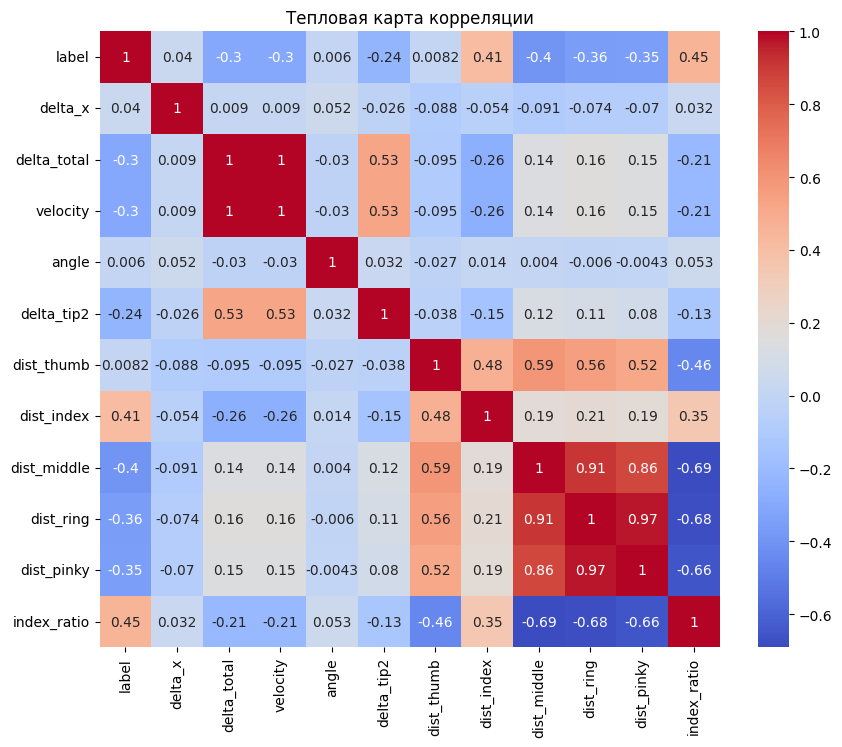

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Тепловая карта корреляции")
plt.show()

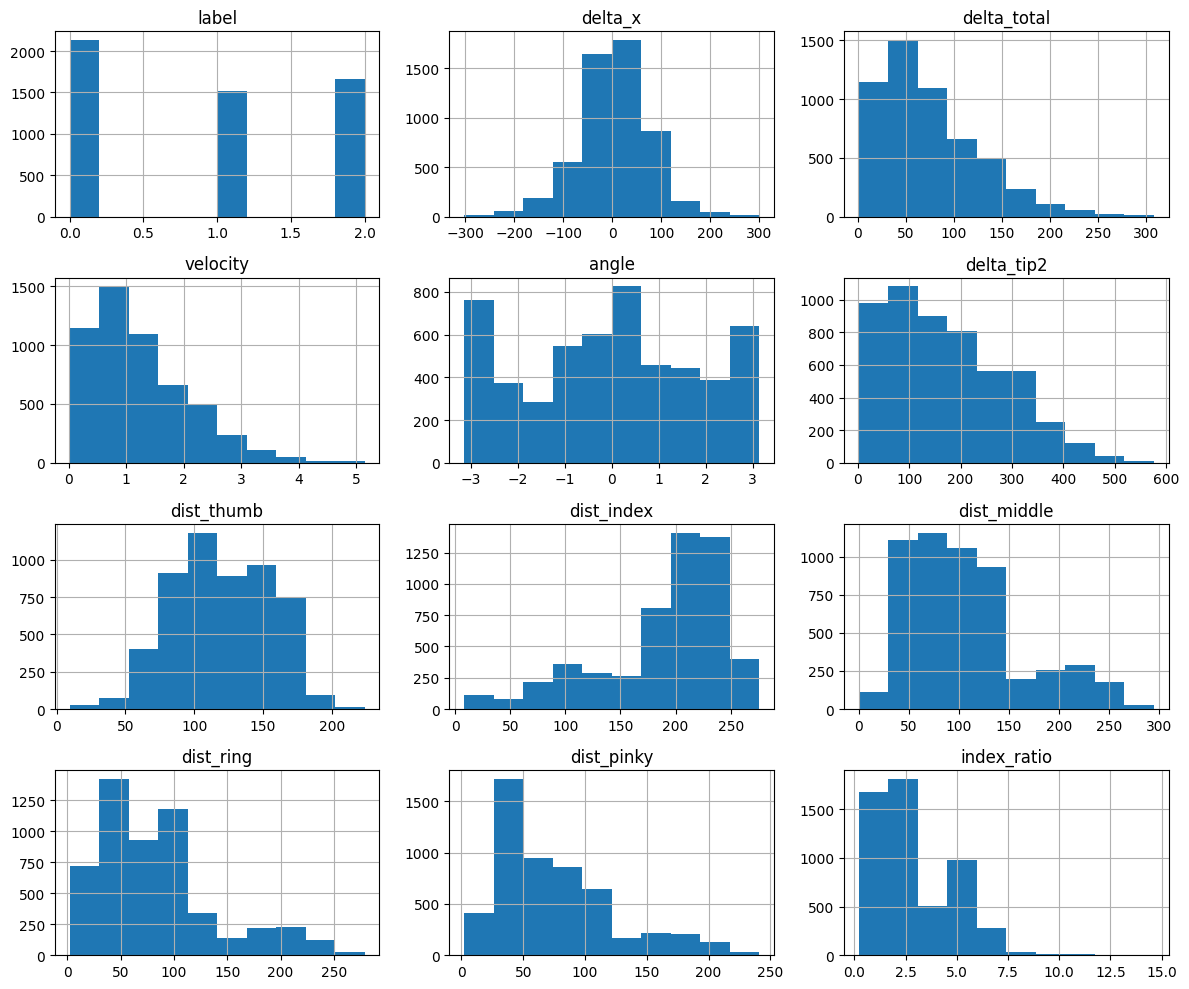

In [16]:
data.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

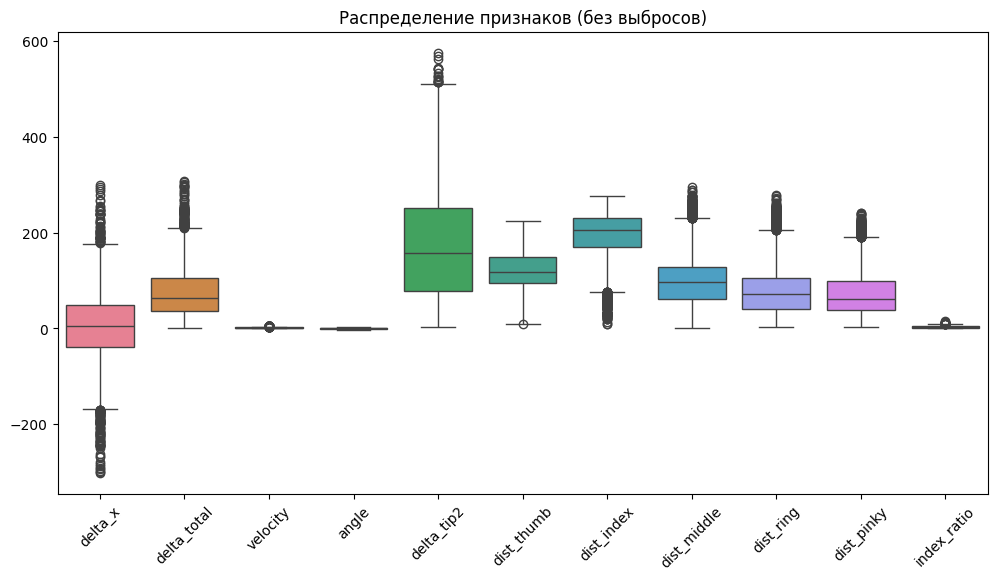

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data.drop('label', axis=1))
plt.xticks(rotation=45)
plt.title("Распределение признаков (без выбросов)")
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Разделение данных
X = data.drop('label', axis=1)
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Обучение модели
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Предсказание и оценка
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       674
           1       0.84      0.87      0.86       454
           2       0.86      0.84      0.85       468

    accuracy                           0.90      1596
   macro avg       0.89      0.89      0.89      1596
weighted avg       0.90      0.90      0.90      1596

Accuracy: 0.90


In [26]:
# Шаг 1: Взвешивание классов
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Шаг 2: Подбор параметров для улучшенной модели
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train, y_train)

# Итоговый отчёт
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.89      0.92       674
           1       0.73      0.87      0.80       454
           2       0.82      0.76      0.79       468

    accuracy                           0.85      1596
   macro avg       0.84      0.84      0.84      1596
weighted avg       0.85      0.85      0.85      1596



In [28]:
# Сохранение
dump(model, 'model.joblib')

['model.joblib']